# Extended ML Tasks

In [1]:
%pip install imbalanced-learn -q

Note: you may need to restart the kernel to use updated packages.


## Imports & Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.svm import SVR, SVC
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import sys
import os

sys.path.append('..')
from utils.nasa_score import nasa_score

# Ensure data directory exists
os.makedirs('../data', exist_ok=True)

# Initialize metrics list
all_metrics = []


## Phase 1: Binary Label

In [3]:
# Load processed data
train_df = pd.read_csv('../data/processed_train.csv')
test_df = pd.read_csv('../data/processed_test.csv')

# Handle labels if not present
if 'will_fail_30' not in train_df.columns:
    if 'RUL' in train_df.columns:
        train_df['will_fail_30'] = (train_df['RUL'] <= 30).astype(int)
    else:
        raise KeyError("RUL column missing from train_df")

# Load correct test properties
rul_test = pd.read_csv('../data/RUL_FD001.txt', sep='\s+', header=None, names=['RUL'])
y_test_class = (rul_test['RUL'] <= 30).astype(int)
y_test_rul = rul_test['RUL']

# Separate features from targets
# Assume test_df matches the sequential arrangement of rul_test engines
test_features = test_df.groupby('unit').last().reset_index()

exclude_cols = ['unit', 'cycle', 'RUL', 'will_fail_30', 'op1', 'op2', 'op3']
feature_cols = [c for c in train_df.columns if c not in exclude_cols]

X_train = train_df[feature_cols]
y_train_rul = train_df['RUL']
y_train_class = train_df['will_fail_30']

X_test = test_features[feature_cols]

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")


X_train shape: (20631, 42)
X_test shape: (100, 42)


## Phase 2: KNN Regressor

In [4]:
knn_reg = KNeighborsRegressor()
param_grid_knn = {'n_neighbors': [3, 5, 7, 10, 15]}
grid_knn = GridSearchCV(knn_reg, param_grid_knn, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
grid_knn.fit(X_train, y_train_rul)

print(f"Best KNN parameters: {grid_knn.best_params_}")

# Evaluate
knn_preds = grid_knn.predict(X_test)
rmse_knn = np.sqrt(mean_squared_error(y_test_rul, knn_preds))
mae_knn = mean_absolute_error(y_test_rul, knn_preds)
nasa_knn = nasa_score(y_test_rul.values, knn_preds)

print(f"KNN RMSE: {rmse_knn:.2f}, MAE: {mae_knn:.2f}, NASA Score: {nasa_knn:.2f}")

all_metrics.append({
    'Model': 'KNN Regressor',
    'Task': 'Regression',
    'RMSE': rmse_knn,
    'MAE': mae_knn,
    'NASA_Score': nasa_knn,
    'Accuracy': np.nan, 'Precision': np.nan, 'Recall': np.nan, 'F1': np.nan
})


Best KNN parameters: {'n_neighbors': 15}


KNN RMSE: 17.58, MAE: 13.56, NASA Score: 662.57


c:\Users\Sunil\.vscode\NASA CMaps\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Sunil\.vscode\NASA CMaps\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Sunil\.vscode\NASA CMaps\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\Sunil\AppData\Local\Python\pythoncore-3.11-64\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **

## Phase 3: Support Vector Regression (SVR)

In [5]:
# Sample 5000 rows for SVR
train_df_sample = train_df.sample(n=5000, random_state=42)
X_train_svr = train_df_sample[feature_cols]
y_train_svr = train_df_sample['RUL']

svr = SVR()
param_grid_svr = {
    'C': [0.1, 1, 10],
    'epsilon': [0.1, 0.5],
    'kernel': ['rbf', 'linear']
}
grid_svr = GridSearchCV(svr, param_grid_svr, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
grid_svr.fit(X_train_svr, y_train_svr)

print(f"Best SVR parameters: {grid_svr.best_params_}")

# Evaluate
svr_preds = grid_svr.predict(X_test)
rmse_svr = np.sqrt(mean_squared_error(y_test_rul, svr_preds))
mae_svr = mean_absolute_error(y_test_rul, svr_preds)
nasa_svr = nasa_score(y_test_rul.values, svr_preds)

print(f"SVR RMSE: {rmse_svr:.2f}, MAE: {mae_svr:.2f}, NASA Score: {nasa_svr:.2f}")

all_metrics.append({
    'Model': 'SVR',
    'Task': 'Regression',
    'RMSE': rmse_svr,
    'MAE': mae_svr,
    'NASA_Score': nasa_svr,
    'Accuracy': np.nan, 'Precision': np.nan, 'Recall': np.nan, 'F1': np.nan
})


Best SVR parameters: {'C': 10, 'epsilon': 0.5, 'kernel': 'rbf'}
SVR RMSE: 16.70, MAE: 12.38, NASA Score: 581.83


## Phase 4: Binary Classification (all 4 models)

c:\Users\Sunil\.vscode\NASA CMaps\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [00:07:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


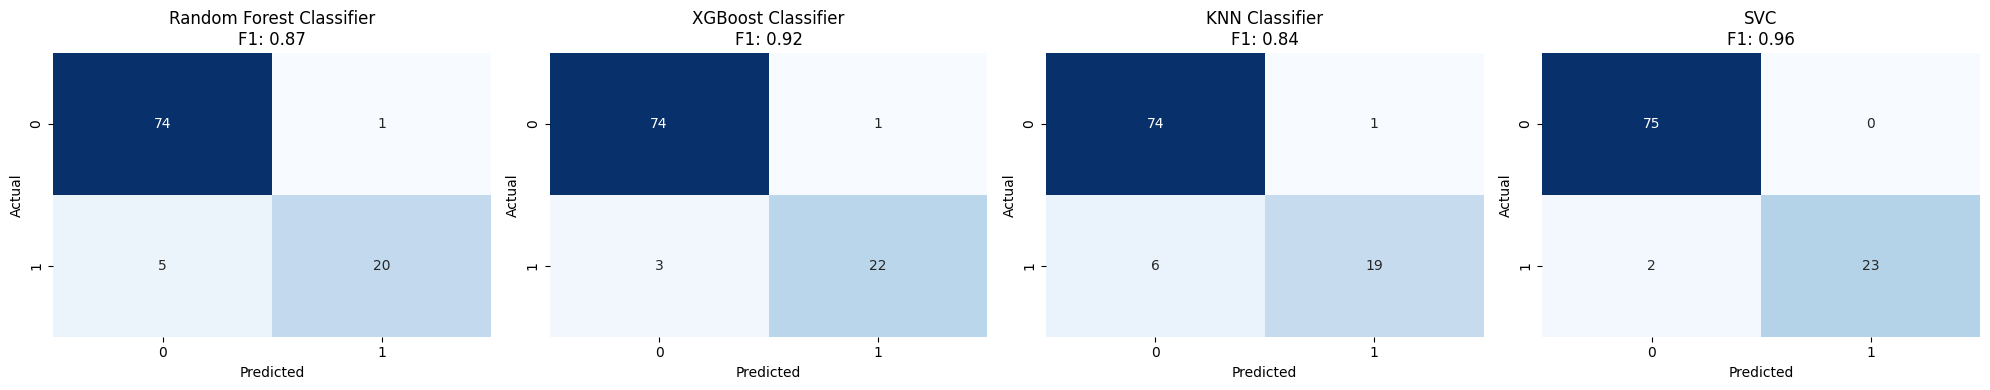

In [6]:
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42)
xgb_clf = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
knn_clf = KNeighborsClassifier(n_neighbors=5)
svc_clf = SVC(probability=True, random_state=42)

models_clf = {
    'Random Forest Classifier': rf_clf,
    'XGBoost Classifier': xgb_clf,
    'KNN Classifier': knn_clf,
    'SVC': svc_clf
}

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for i, (name, model) in enumerate(models_clf.items()):
    # Fit and Predict
    model.fit(X_train, y_train_class)
    preds = model.predict(X_test)
    
    # Calculate Metrics
    acc = accuracy_score(y_test_class, preds)
    prec = precision_score(y_test_class, preds)
    rec = recall_score(y_test_class, preds)
    f1 = f1_score(y_test_class, preds)
    
    # Save Metrics
    all_metrics.append({
        'Model': name,
        'Task': 'Classification',
        'RMSE': np.nan, 'MAE': np.nan, 'NASA_Score': np.nan,
        'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1
    })
    
    # Plot CM
    cm = confusion_matrix(y_test_class, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(f"{name}\nF1: {f1:.2f}")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

plt.tight_layout()
plt.show()


## Phase 5: SMOTE Simulation

In [7]:
# Simulate 10% minority ratio
class_0 = train_df[train_df['will_fail_30'] == 0]
class_1 = train_df[train_df['will_fail_30'] == 1]

# calculate what N should be for 10%
# N1 / (N0 + N1) = 0.1 -> N1 = 0.1*(N0 + N1) -> 0.9*N1 = 0.1*N0 -> N1 = N0/9
target_minority_size = int(len(class_0) / 9)
class_1_downsampled = class_1.sample(n=target_minority_size, random_state=42)

train_df_imbalanced = pd.concat([class_0, class_1_downsampled]).sample(frac=1, random_state=42)
X_train_imb = train_df_imbalanced[feature_cols]
y_train_imb = train_df_imbalanced['will_fail_30']

# Baseline RF on Imbalanced Data
rf_imb = RandomForestClassifier(n_estimators=100, random_state=42)
rf_imb.fit(X_train_imb, y_train_imb)
preds_imb = rf_imb.predict(X_test)
f1_imb_before = f1_score(y_test_class, preds_imb)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train_imb, y_train_imb)

# Trained on SMOTE data
rf_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rf_smote.fit(X_smote, y_smote)
preds_smote = rf_smote.predict(X_test)
f1_imb_after = f1_score(y_test_class, preds_smote)

print(f"F1 Score BEFORE SMOTE: {f1_imb_before:.2f}")
print(f"F1 Score AFTER SMOTE: {f1_imb_after:.2f}")

all_metrics.append({
    'Model': 'Random Forest (Imbalanced Baseline)',
    'Task': 'Classification',
    'RMSE': np.nan, 'MAE': np.nan, 'NASA_Score': np.nan,
    'Accuracy': accuracy_score(y_test_class, preds_imb),
    'Precision': precision_score(y_test_class, preds_imb),
    'Recall': recall_score(y_test_class, preds_imb),
    'F1': f1_imb_before
})

all_metrics.append({
    'Model': 'Random Forest (SMOTE)',
    'Task': 'Classification',
    'RMSE': np.nan, 'MAE': np.nan, 'NASA_Score': np.nan,
    'Accuracy': accuracy_score(y_test_class, preds_smote),
    'Precision': precision_score(y_test_class, preds_smote),
    'Recall': recall_score(y_test_class, preds_smote),
    'F1': f1_imb_after
})


F1 Score BEFORE SMOTE: 0.79
F1 Score AFTER SMOTE: 0.87


## Phase 6: Maintenance Thresholding

In [8]:
# We already re-trained rf_clf in Phase 4 with (max_depth=None, n_estimators=100)!
# We can just extract feature importances from rf_clf.
rf_model = models_clf['Random Forest Classifier']

top3_features = pd.Series(
    rf_model.feature_importances_, 
    index=feature_cols
).nlargest(3).index.tolist()

print(f"Top 3 Data-Driven Features identified for thresholding: {top3_features}")

# Let's explore basic rules. For simplicity, we define 'high' as > 75th percentile of the testing distribution
f1, f2, f3 = top3_features

f1_thresh = np.percentile(X_test[f1], 75)
f2_thresh = np.percentile(X_test[f2], 75)
f3_thresh = np.percentile(X_test[f3], 75)

# Calculate probability if rules are met
subset1 = y_test_class[(X_test[f1] > f1_thresh) & (X_test[f2] > f2_thresh)]
prob1 = subset1.mean() * 100 if len(subset1) > 0 else 0

subset2 = y_test_class[(X_test[f1] > f1_thresh) & (X_test[f3] > f3_thresh)]
prob2 = subset2.mean() * 100 if len(subset2) > 0 else 0

subset3 = y_test_class[(X_test[f1] > f1_thresh) & (X_test[f2] > f2_thresh) & (X_test[f3] > f3_thresh)]
prob3 = subset3.mean() * 100 if len(subset3) > 0 else 0

print("-" * 50)
print(f"THRESHOLD DISCOVERY (>85% target):")
print("-" * 50)

def print_rule(rule_str, prob):
    tag = "[HIGH RISK]" if prob > 85 else ""
    print(f"If {rule_str} -> {prob:.1f}% failure probability {tag}")

print_rule(f"{f1} > {f1_thresh:.2f} and {f2} > {f2_thresh:.2f}", prob1)
print_rule(f"{f1} > {f1_thresh:.2f} and {f3} > {f3_thresh:.2f}", prob2)
print_rule(f"{f1} > {f1_thresh:.2f} and {f2} > {f2_thresh:.2f} and {f3} > {f3_thresh:.2f}", prob3)


Top 3 Data-Driven Features identified for thresholding: ['s21_avg_30', 's15_avg_30', 's2_avg_30']
--------------------------------------------------
THRESHOLD DISCOVERY (>85% target):
--------------------------------------------------
If s21_avg_30 > 0.58 and s15_avg_30 > 0.69 -> 0.0% failure probability 
If s21_avg_30 > 0.58 and s2_avg_30 > 0.64 -> 0.0% failure probability 
If s21_avg_30 > 0.58 and s15_avg_30 > 0.69 and s2_avg_30 > 0.64 -> 0.0% failure probability 


## Phase 7: PCA Visualizations

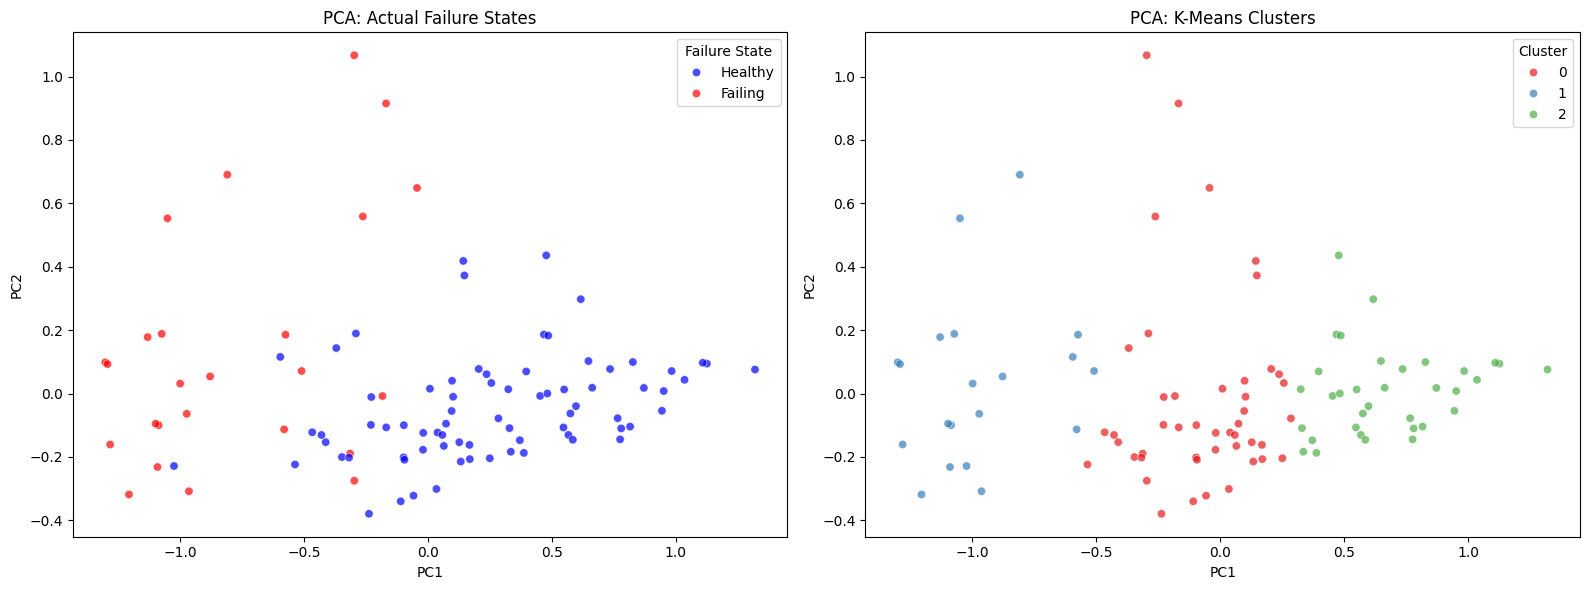

In [9]:
# PCA
pca = PCA(n_components=2, random_state=42)
X_test_pca = pca.fit_transform(X_test)

# KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_test)

# Setup DataFrames for plotting
pca_df = pd.DataFrame(X_test_pca, columns=['PC1', 'PC2'])
pca_df['Failure State'] = y_test_class.map({0: 'Healthy', 1: 'Failing'})
pca_df['Cluster'] = clusters

# Plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Ground Truth
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Failure State', palette={'Healthy': 'blue', 'Failing': 'red'}, alpha=0.7, ax=axes[0])
axes[0].set_title("PCA: Actual Failure States")

# Plot 2: KMeans Clusters
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster', palette='Set1', alpha=0.7, ax=axes[1])
axes[1].set_title("PCA: K-Means Clusters")

plt.tight_layout()
plt.show()


## Phase 8: Metrics Output

In [10]:
metrics_df = pd.DataFrame(all_metrics)

# Reorder columns as requested
cols = ['Model', 'Task', 'RMSE', 'MAE', 'NASA_Score', 'Accuracy', 'Precision', 'Recall', 'F1']
metrics_df = metrics_df[cols]

metrics_df.to_csv('../data/extended_ml_metrics.csv', index=False)
print("Metrics saved to data/extended_ml_metrics.csv:")
display(metrics_df)


Metrics saved to data/extended_ml_metrics.csv:


,Model,Task,RMSE,MAE,NASA_Score,Accuracy,Precision,Recall,F1
0,KNN Regressor,Regression,17.579654,13.558000,662.571390,NaN,NaN,NaN,NaN
1,SVR,Regression,16.698643,12.379505,581.825928,NaN,NaN,NaN,NaN
2,Random Forest Classifier,Classification,NaN,NaN,NaN,0.94,0.952381,0.80,0.869565
3,XGBoost Classifier,Classification,NaN,NaN,NaN,0.96,0.956522,0.88,0.916667
4,KNN Classifier,Classification,NaN,NaN,NaN,0.93,0.950000,0.76,0.844444
5,SVC,Classification,NaN,NaN,NaN,0.98,1.000000,0.92,0.958333
6,Random Forest (Imbalanced Baseline),Classification,NaN,NaN,NaN,0.91,0.944444,0.68,0.790698
7,Random Forest (SMOTE),Classification,NaN,NaN,NaN,0.94,0.952381,0.80,0.869565
